# Comparing Cosmetics by Ingredients:

## Cosmetics, chemicals... it's complicated


<p>Whenever I want to try a new cosmetic item, it's so difficult to choose. It's actually more than difficult. It's sometimes scary because new items that I've never tried end up giving me skin trouble. We know the information we need is on the back of each product, but it's really hard to interpret those ingredient lists unless you're a chemist. You may be able to relate to this situation. For example, the picture below shows ingredients of a cosmetic product, and are very difficult for the general public to understand.</p>
<p><img src="https://assets.datacamp.com/production/project_695/img/image_1.png" style="width:600px;height:400px;"></p>
<p>So instead of buying and hoping for the best, why don't we use machine learning to help us predict which products may be good fits for us? In this project, I am going to create a content-based recommendation system where the 'content' will be the chemical components of cosmetics. Specifically, I will process ingredient lists for 1472 cosmetics on Sephora via <a href="https://en.wikipedia.org/wiki/Word_embedding">word embedding</a>, then visualize ingredient similarity using a machine learning method called t-SNE and an interactive visualization library called Bokeh.</p>

In addition to utilizing t-SNE for visualizing the similarity between various products based on their ingredients, I intend to extend this project by developing a machine learning model. This model will take product information, including ingredients, as input and predict the skin types for which the product is suitable.

By leveraging machine learning techniques, this model aims to offer a practical solution for consumers seeking products tailored to their specific skincare needs. This approach goes beyond simple visualization and enables automated decision-making based on product attributes, potentially enhancing the efficiency and accuracy of skincare product selection.

## Importing libraries and dataset:

Let us start off by importing the necessary libaries for this project:

In [76]:
# Import all necessary libraries
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from bokeh.io import show, output_notebook, push_notebook
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool, Legend
from bokeh.models import Segment
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import multilabel_confusion_matrix
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import layers, models

Next, let's load the dataset:

In [77]:
# Load the data
df = pd.read_csv("datasets/cosmetics.csv")

In [78]:
# Check the first five rows 
df.head(5)

,Label,Brand,Name,Price,Rank,Ingredients,Combination,Dry,Normal,Oily,Sensitive
0,Moisturizer,LA MER,Crème de la Mer,175,4.1,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",1,1,1,1,1
1,Moisturizer,SK-II,Facial Treatment Essence,179,4.1,"Galactomyces Ferment Filtrate (Pitera), Butyle...",1,1,1,1,1
2,Moisturizer,DRUNK ELEPHANT,Protini™ Polypeptide Cream,68,4.4,"Water, Dicaprylyl Carbonate, Glycerin, Ceteary...",1,1,1,1,0
3,Moisturizer,LA MER,The Moisturizing Soft Cream,175,3.8,"Algae (Seaweed) Extract, Cyclopentasiloxane, P...",1,1,1,1,1
4,Moisturizer,IT COSMETICS,Your Skin But Better™ CC+™ Cream with SPF 50+,38,4.1,"Water, Snail Secretion Filtrate, Phenyl Trimet...",1,1,1,1,1


In [79]:
# Check if there are nulls
df.isna().sum()

Label          0
Brand          0
Name           0
Price          0
Rank           0
Ingredients    0
Combination    0
Dry            0
Normal         0
Oily           0
Sensitive      0
dtype: int64

There are no Null values in our dataset.

In [80]:
print(f"This is the shape before dropping duplicates: {df.shape}")
df = df.drop_duplicates()
print(f"This is the shape after dropping duplicates: {df.shape}")

This is the shape before dropping duplicates: (1472, 11)
This is the shape after dropping duplicates: (1472, 11)


As we can see from the results above, there were not duplicates and therefore `drop_duplicates` did not drop anything.

Let us now look at the different columns in our dataset and their data type:

In [81]:
# Inspect the types of products
print(df.dtypes)

Label           object
Brand           object
Name            object
Price            int64
Rank           float64
Ingredients     object
Combination      int64
Dry              int64
Normal           int64
Oily             int64
Sensitive        int64
dtype: object


Let us try to understand what each column means here:

1. **Label**: Indicates the category or type of cosmetic product (e.g., Moisturizer).

2. **Brand**: Specifies the brand or manufacturer of the cosmetic product.

3. **Name**: Represents the name or title of the specific cosmetic product.

4. **Price**: Denotes the price of the cosmetic product.

5. **Rank**: Likely represents a ranking or rating associated with each cosmetic product, indicating its perceived quality, popularity, or effectiveness. The higher the rank, the better the product is perceived to be.

6. **Ingredients**: Lists the ingredients used in the formulation of the cosmetic product. These ingredients contribute to the product's properties and functionality.

7. **Combination**: Indicates whether the cosmetic product is suitable for combination skin type (1 for yes, 0 for no).

8. **Dry**: Indicates whether the cosmetic product is suitable for dry skin type (1 for yes, 0 for no).

9. **Normal**: Indicates whether the cosmetic product is suitable for normal skin type (1 for yes, 0 for no).

10. **Oily**: Indicates whether the cosmetic product is suitable for oily skin type (1 for yes, 0 for no).

11. **Sensitive**: Indicates whether the cosmetic product is suitable for sensitive skin type (1 for yes, 0 for no).

These columns provide various attributes and characteristics of cosmetic products, helping consumers make informed decisions based on their preferences and skin types.

## Analysing the columns further to understand them better:

Let's try to analyze the 'rank' column since it is a little ambigious. Although we know that is probably corresponds to the rating - we don't know the maximum value that the rating could take and other statistics about that column. To obtain that:

In [82]:
df['Rank'].unique()

array([4.1, 4.4, 3.8, 4.2, 5. , 4.3, 4.5, 4.6, 3.9, 4. , 3.7, 4.8, 4.7,
       0. , 3.3, 3.6, 3.5, 4.9, 3.4, 2.8, 2. , 3.1, 2.6, 3. , 3.2, 1. ,
       2.9, 2.7, 1.8])

In [83]:
df['Rank'].describe()

count    1472.000000
mean        4.153261
std         0.633918
min         0.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rank, dtype: float64

By observing the unique values and the distribution of the column, it seems like the 'Rank' column ranges from 0 to 5, with 0 being the lowest rating to 5 being the highest rating. It also seems like the average of the rankings/ratings is very high, of about 4.15/5 - meaning most products in this dataset are reviewed highly, therefore providing us with a good quality dataset to analyze.

Now, let us look at the 'Label' column to see the distribution of products in our dataset:

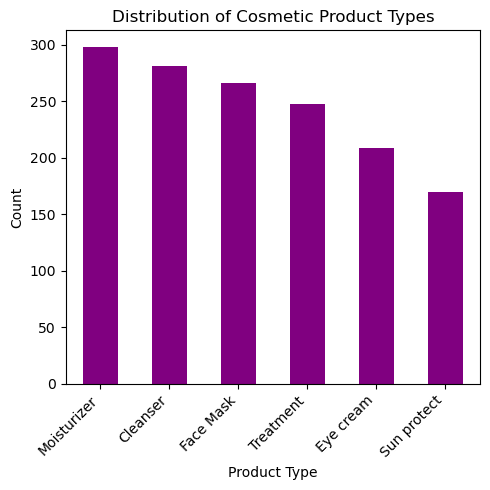

In [84]:
# Count the frequency of each label
label_counts = df['Label'].value_counts()

# Create a bar plot
plt.figure(figsize=(5, 5))
label_counts.plot(kind='bar', color='purple')
plt.title('Distribution of Cosmetic Product Types')
plt.xlabel('Product Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


Let's look at the number of record for each skin type to try and see if there may be any class imbalances in the dataset:

In [85]:
df_skin_types = df[['Combination','Dry','Normal','Oily','Sensitive']]
df_skin_types

,Combination,Dry,Normal,Oily,Sensitive
0,1,1,1,1,1
1,1,1,1,1,1
2,1,1,1,1,0
3,1,1,1,1,1
4,1,1,1,1,1
...,...,...,...,...,...
1467,1,1,1,1,1
1468,0,0,0,0,0
1469,0,0,0,0,0
1470,0,0,0,0,0


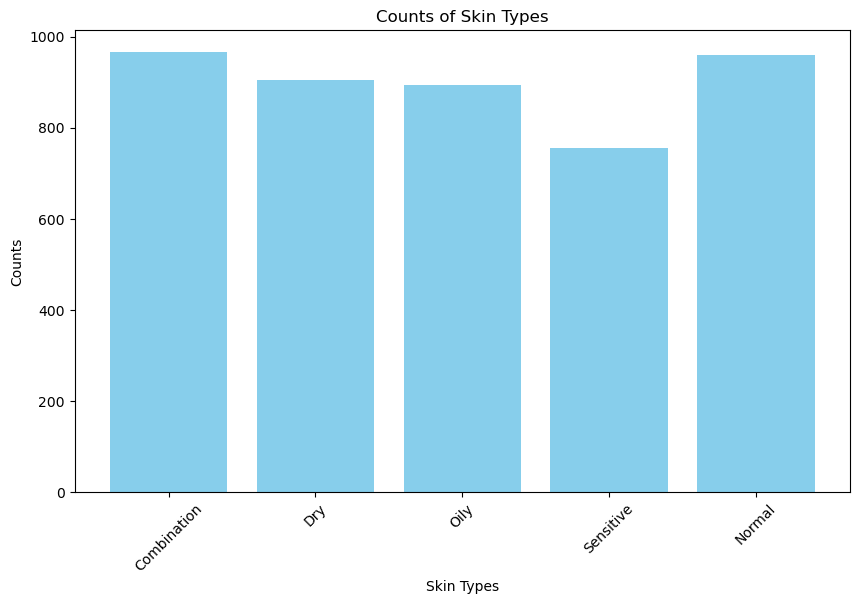

In [86]:
combination = df_skin_types['Combination'].sum()
dry = df_skin_types['Dry'].sum()
oily = df_skin_types['Oily'].sum()
sensitive = df_skin_types['Sensitive'].sum()
normal = df_skin_types['Normal'].sum()

skin_types = ['Combination', 'Dry', 'Oily', 'Sensitive', 'Normal']
counts = [combination, dry, oily, sensitive, normal]

plt.figure(figsize=(10, 6))
plt.bar(skin_types, counts, color='skyblue')
plt.xlabel('Skin Types')
plt.ylabel('Counts')
plt.title('Counts of Skin Types')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()


It seems like all classes are well represented, and there is no one class that is over/under represented compared to the others.

**Now let us move on to pre-processing our data for t-SNE and other ML models:**

## Pre-processing:

## Tokenizing the ingredients
<p>To get to our goal of comparing ingredients in each product, we first need to do some preprocessing tasks and bookkeeping of the actual words in each product's ingredients list. The first step will be tokenizing the list of ingredients in <code>Ingredients</code> column. After splitting them into tokens, we'll make a binary bag of words. Then we will create a dictionary with the tokens, <code>ingredient_idx</code>, which will have the following format:</p>
<p>{ <strong><em>"ingredient"</em></strong>: index value, … }</p>

###  We are using binary bag of words to make it easier for the ML algorithm to use numerical features to learn the model

In [87]:
# Initialize dictionary, list, and initial index
ingredient_idx = {}
corpus = [] # list of ingredients in each row
idx = 0

# For loop for tokenization
for i in range(len(df)):    
    ingredients = df['Ingredients'][i]
    ingredients_lower = ingredients.lower()
    tokens = ingredients_lower.split(', ')
    corpus.append(tokens)
    for ingredient in tokens:
        if ingredient not in ingredient_idx.keys():
            ingredient_idx[ingredient] = idx
            idx += 1 # To ensure that each unique ingredient is assigned a unique index

In [88]:
# This now has a list of all the unique ingredients in their order of appearance
ingredient_idx 

{'algae (seaweed) extract': 0,
 'mineral oil': 1,
 'petrolatum': 2,
 'glycerin': 3,
 'isohexadecane': 4,
 'microcrystalline wax': 5,
 'lanolin alcohol': 6,
 'citrus aurantifolia (lime) extract': 7,
 'sesamum indicum (sesame) seed oil': 8,
 'eucalyptus globulus (eucalyptus) leaf oil': 9,
 'sesamum indicum (sesame) seed powder': 10,
 'medicago sativa (alfalfa) seed powder': 11,
 'helianthus annuus (sunflower) seedcake': 12,
 'prunus amygdalus dulcis (sweet almond) seed meal': 13,
 'sodium gluconate': 14,
 'copper gluconate': 15,
 'calcium gluconate': 16,
 'magnesium gluconate': 17,
 'zinc gluconate': 18,
 'magnesium sulfate': 19,
 'paraffin': 20,
 'tocopheryl succinate': 21,
 'niacin': 22,
 'water': 23,
 'beta-carotene': 24,
 'decyl oleate': 25,
 'aluminum distearate': 26,
 'octyldodecanol': 27,
 'citric acid': 28,
 'cyanocobalamin': 29,
 'magnesium stearate': 30,
 'panthenol': 31,
 'limonene': 32,
 'geraniol': 33,
 'linalool': 34,
 'hydroxycitronellal': 35,
 'citronellol': 36,
 'benzyl 

## Initializing a document-term matrix (DTM)
<p>The next step is making a document-term matrix (DTM). Here each cosmetic product will correspond to a document, and each chemical composition will correspond to a term. This means we can think of the matrix as a <em>“cosmetic-ingredient”</em> matrix. The size of the matrix should be as the picture shown below.
<img src="https://assets.datacamp.com/production/project_695/img/image_2.PNG" style="width:600px;height:250px;">
</p> To create this matrix, we'll first make an empty matrix filled with zeros. The length of the matrix is the total number of cosmetic products in the data. The width of the matrix is the total number of ingredients. After initializing this empty matrix, we'll fill it in the following tasks. </p>

In [89]:
# Get the number of unique ingredients and the number of rows (cosmetics) 
M = len(df)
N = len(ingredient_idx)

# Initialize a matrix of zeros
A = np.zeros((M,N))

In [90]:
A.shape # Verifying that the shape is as required - we have all the 1472 rows with one column per unique ingredient

(1472, 6833)

## Creating a counter function
<p>Before we can fill the matrix, let's create a function to count the tokens (i.e., an ingredients list) for each row. Our end goal is to fill the matrix with 1 or 0: if an ingredient is in a cosmetic, the value is 1. If not, it remains 0. 

In [91]:
# Define the oh_encoder function to do one hot encoding for the ingredients
def oh_encoder(tokens):
    x = np.zeros(len(ingredient_idx)) # has as many rows as the total # of ingredients
    for ingredient in tokens:
        # Get the index for each ingredient
        idx = ingredient_idx[ingredient]
        # Put 1 at the corresponding indices
        x[idx] = 1 # x is a vector corresponding to each cosmetics- filled with 1s at positions where the ingredient is present
    return x

## 6. The Cosmetic-Ingredient matrix!
<p>Now we'll apply the <code>oh_encoder()</code> functon to the tokens in <code>corpus</code> and set the values at each row of this matrix. So the result will tell us what ingredients each item is composed of. For example, if a cosmetic item contains <em>water, niacin, decyl aleate</em> and <em>sh-polypeptide-1</em>, the outcome of this item will be as follows. 
<img src="https://assets.datacamp.com/production/project_695/img/image_3.PNG" style="width:800px;height:400px;">

By encoding each ingredient in the items, the <em>Cosmetic-Ingredient</em> matrix will be filled with binary values. </p>

In [92]:
# Make a document-term matrix
i = 0
# Corpus is a list of lists that has the ingredients of each product 
for tokens in corpus:
    A[i, :] = oh_encoder(tokens) # For each product, create the 'x' vector the tells us which ingredients are present in each product
    i += 1

## Dimension reduction with t-SNE
<p>The dimensions of the existing matrix is (1472, 6833), which means there are 6833 features in our data. For visualization, we should downsize this into two dimensions. We'll use t-SNE for reducing the dimension of the data here.</p>
<p><strong><a href="https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding">T-distributed Stochastic Neighbor Embedding (t-SNE)</a></strong> is a nonlinear dimensionality reduction technique that is well-suited for embedding high-dimensional data for visualization in a low-dimensional space of two or three dimensions. Specifically, this technique can reduce the dimension of data while keeping the similarities between the instances. This enables us to make a plot on the coordinate plane, which can be said as vectorizing. All of these cosmetic items in our data will be vectorized into two-dimensional coordinates, and the distances between the points will indicate the similarities between the items. </p>

In [93]:
# Dimensionality reduction using t-SNE
seed = 42 # seed for reproducability
model = TSNE(n_components = 2, learning_rate = 200, random_state = seed)
tsne_features = model.fit_transform(A)

df_TSNE = df.copy()

# Make X, Y columns 
df_TSNE['X'] = tsne_features[:,0]
df_TSNE['Y'] = tsne_features[:,1]

Let us display the new dataframe df_TSNE that now has an `X` and `Y` t-SNE coordinate

In [94]:
df_TSNE # now has 2 new columns X and Y that correspond to the t-SNE coordinates

,Label,Brand,Name,Price,Rank,Ingredients,Combination,Dry,Normal,Oily,Sensitive,X,Y
0,Moisturizer,LA MER,Crème de la Mer,175,4.1,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",1,1,1,1,1,76.995239,36.197010
1,Moisturizer,SK-II,Facial Treatment Essence,179,4.1,"Galactomyces Ferment Filtrate (Pitera), Butyle...",1,1,1,1,1,-23.662107,47.678776
2,Moisturizer,DRUNK ELEPHANT,Protini™ Polypeptide Cream,68,4.4,"Water, Dicaprylyl Carbonate, Glycerin, Ceteary...",1,1,1,1,0,-36.549240,12.054488
3,Moisturizer,LA MER,The Moisturizing Soft Cream,175,3.8,"Algae (Seaweed) Extract, Cyclopentasiloxane, P...",1,1,1,1,1,73.067955,53.230659
4,Moisturizer,IT COSMETICS,Your Skin But Better™ CC+™ Cream with SPF 50+,38,4.1,"Water, Snail Secretion Filtrate, Phenyl Trimet...",1,1,1,1,1,-81.698143,-34.347206
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1467,Sun protect,KORRES,Yoghurt Nourishing Fluid Veil Face Sunscreen B...,35,3.9,"Water, Alcohol Denat., Potassium Cetyl Phospha...",1,1,1,1,1,30.144087,-26.629322
1468,Sun protect,KATE SOMERVILLE,Daily Deflector™ Waterlight Broad Spectrum SPF...,48,3.6,"Water, Isododecane, Dimethicone, Butyloctyl Sa...",0,0,0,0,0,-78.589012,33.521191
1469,Sun protect,VITA LIBERATA,Self Tan Dry Oil SPF 50,54,3.5,"Water, Dihydroxyacetone, Glycerin, Sclerocarya...",0,0,0,0,0,16.325211,-34.210335
1470,Sun protect,ST. TROPEZ TANNING ESSENTIALS,Pro Light Self Tan Bronzing Mist,20,1.0,"Water, Dihydroxyacetone, Propylene Glycol, PPG...",0,0,0,0,0,11.660785,-26.434437


## Let's map the items with Bokeh
<p> With the t-SNE values, we can plot all our items on the coordinate plane. Let's make a scatter plot using Bokeh and add a hover tool to show that information.</p>

In [95]:
output_notebook()

# Define colors for each label
label_colors = {
    'Moisturizer': '#FF7373',  # Red
    'Cleanser': '#73FF73',      # Green
    'Treatment': '#7373FF',     # Blue
    'Face Mask': '#FF73FF',     # Purple
    'Eye cream': '#FFFF73',     # Yellow
    'Sun protect': '#73FFFF',   # Cyan
}

# Create the scatter plot
plot = figure(x_axis_label='T-SNE 1', 
              y_axis_label='T-SNE 2', 
              title="T-SNE Plot with Cosmetic Labels",
              width=1000, height= 800)

# Plot the data points, assigning colors based on the 'label' column
renderers = []
for label, color in label_colors.items():
    subset_source = ColumnDataSource(df_TSNE[df_TSNE['Label'] == label])
    renderer = plot.circle(x='X', y='Y', source=subset_source, size=10, color=color, alpha=0.8, legend_label=label)
    renderers.append(renderer)

# Add the legend
legend = Legend(items=[(label, [renderer]) for label, renderer in zip(label_colors.keys(), renderers)],
                location='top_left')

Loading BokehJS ...

Adding a hover tool allows us to check the information of each item whenever the cursor is directly over a glyph. We'll add tooltips with each product's name, brand, price, rank (i.e., rating), label, and the 5 different skin types and whether they are suitable for those or not (indicated by the presence of 0 or 1).</p>

In [96]:
# Create a HoverTool object
hover = HoverTool(tooltips = [('Item', '@Name'),
                              ('Brand', '@Brand'),
                              ('Price', '@Price'),
                              ('Rank', '@Rank'),
                              ('Label', '@Label'),
                              ('Dry', '@Dry'),
                              ('Sensitive', '@Sensitive'),
                              ('Combination', '@Combination'),
                              ('Normal', '@Normal'),
                              ('Oily', '@Oily'),
                              ])
plot.add_tools(hover)

## Mapping the cosmetic items
<p>Finally, it's time to plot the t-SNE plot. Each point on the plot corresponds to the cosmetic items. The axes of a t-SNE plot aren't easily interpretable in terms of the original data. Like mentioned above, t-SNE is a visualizing technique to plot high-dimensional data in a low-dimensional space. Therefore, it's not desirable to interpret a t-SNE plot quantitatively.</p>
<p>Instead, what we can get from this map is the distance between the points (which items are close and which are far apart). The closer the distance between the two items is, the more similar the composition they have. Therefore this enables us to compare the items without having any chemistry background.</p>

In [97]:
# Plot the map
show(plot)

## Comparing two products
<p>Since there are so many cosmetics and so many ingredients, the plot doesn't have many super obvious patterns that some simpler t-SNE plots may have.</p> But this is still extremely useful.
<p>Say we enjoyed a specific product, there's an increased chance we'd enjoy another product that is similar in chemical composition.  Say we enjoyed AmorePacific's <a href="https://www.sephora.com/product/color-control-cushion-compact-broad-spectrum-spf-50-P378121">Color Control Cushion Compact Broad Spectrum SPF 50+</a>. We could find this product on the plot and see if a similar product(s) exist. 

In [98]:
# Print the row of the cosmetics that you enjoyed using
cosmetic_1 = df_TSNE[df_TSNE['Name'] == "Color Control Cushion Compact Broad Spectrum SPF 50+"]

# Display the item's data and ingredients
display(cosmetic_1)

,Label,Brand,Name,Price,Rank,Ingredients,Combination,Dry,Normal,Oily,Sensitive,X,Y
61,Moisturizer,AMOREPACIFIC,Color Control Cushion Compact Broad Spectrum S...,60,4.0,"Phyllostachis Bambusoides Juice, Cyclopentasil...",1,1,1,1,1,-59.090145,-32.142281


Let us see where this product lies on the plot:

In [99]:
# Plot a line at specific x and y coordinates
line_x = -59.090145  # Specify the x-coordinate on the t-SNE plot
line_y = -32.142281  # Specify the y-coordinate on the t-SNE plot

# Add the vertical line segment
plot.add_glyph(Segment(x0=line_x, y0=-200, x1=line_x, y1=200, line_color='black', line_dash='dashed', line_width=2))

# Add the horizontal line segment
plot.add_glyph(Segment(x0=-200, y0=line_y, x1=200, y1=line_y, line_color='black', line_dash='dashed', line_width=2))

# Show the plot
show(plot)

An example usage of this plot would be as shown above. We know that at the intersection of the dashed lines lies a product that we enjoyed using. If we hover near the intersection, we can find other products similar to this one, and the skin types it's suitable for, it's label, rating, price and of course it's name and brand, making it easier to purchase an alternative product similar to one that suits your skin!

In the part above, I used t-SNE to visualize similarity between products by their ingredients. However, I want to extend this further, and create a machine learning model that takes in a product's information as it's input, and outputs whether or not it is suitable for the 5 different skin types - Dry, Oily, Sensitive, Normal, Combination.

## Further data preprocessing/feature engineering for ML models

t-SNE is primarily used for visualization rather than feature engineering. Its main purpose is to reduce the dimensionality of high-dimensional data while preserving local and global structures, making it suitable for creating 2D or 3D visualizations that reveal patterns or clusters in the data.

While t-SNE can provide valuable insights into the structure of our data and help guide feature engineering decisions, it is not typically used directly for feature engineering in the same way as other techniques like PCA (Principal Component Analysis) or LDA (Linear Discriminant Analysis). These techniques focus more on transforming the data to extract relevant features or reduce noise, whereas t-SNE is focused on visualization.

Therefore, now we will be using PCA to engineer new (condensed) features to use in our Machine learning model.

The array `A` had the one-hot encoded output for each of the 1472 rows of cosmetics and the corresponding 6833 ingredients. Let us view it in the form of a dataframe to use ML on

In [100]:
df_new = pd.DataFrame(A) # convert array to dataframe
df_new # Display the resulting df

,0,1,2,3,4,5,6,7,8,9,...,6823,6824,6825,6826,6827,6828,6829,6830,6831,6832
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1467,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1468,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1469,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1470,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Since df_new has the ingredient names as numbers (column names), let's replace the column indices with the ingredient they represent:

In [101]:
# Swap keys and values in the dictionary
ingredient_idx_swapped = {v: k for k, v in ingredient_idx.items()}

# Rename the columns using the swapped dictionary
df_new_renamed = df_new.rename(columns=ingredient_idx_swapped)

# View new df
df_new_renamed

,algae (seaweed) extract,mineral oil,petrolatum,glycerin,isohexadecane,microcrystalline wax,lanolin alcohol,citrus aurantifolia (lime) extract,sesamum indicum (sesame) seed oil,eucalyptus globulus (eucalyptus) leaf oil,...,chlorhexidine digluconate. [+/-: iron oxides (ci 77491,-pepha® (derived from watermelon extract): protects skin cells against daily stress. - vitasource™ and dglyage®: firm the appearance of skin,support elasticity,and fight wrinkles. -light-diffusing spheres: provide a professionally retouched look.,lentinus edodes extract,sodium lignosulfonate,sodium carboxyethylsilanetriol,ozonized oryza sativa (rice) callus culture extract,methylcellulose,visit the dermaflash boutique
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1467,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1468,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1469,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1470,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


There are 6833 unique ingredients

Let us concatenate the encoded ingredients with the rest of the columns in df:

In [102]:
df.columns

Index(['Label', 'Brand', 'Name', 'Price', 'Rank', 'Ingredients', 'Combination',
       'Dry', 'Normal', 'Oily', 'Sensitive'],
      dtype='object')

In [103]:
df_ingr_encoded = pd.concat([df[['Label', 'Brand', 'Name', 'Price', 'Rank', 'Combination',
       'Dry', 'Normal', 'Oily', 'Sensitive']], df_new_renamed], axis = 1)
df_ingr_encoded

,Label,Brand,Name,Price,Rank,Combination,Dry,Normal,Oily,Sensitive,...,chlorhexidine digluconate. [+/-: iron oxides (ci 77491,-pepha® (derived from watermelon extract): protects skin cells against daily stress. - vitasource™ and dglyage®: firm the appearance of skin,support elasticity,and fight wrinkles. -light-diffusing spheres: provide a professionally retouched look.,lentinus edodes extract,sodium lignosulfonate,sodium carboxyethylsilanetriol,ozonized oryza sativa (rice) callus culture extract,methylcellulose,visit the dermaflash boutique
0,Moisturizer,LA MER,Crème de la Mer,175,4.1,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Moisturizer,SK-II,Facial Treatment Essence,179,4.1,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Moisturizer,DRUNK ELEPHANT,Protini™ Polypeptide Cream,68,4.4,1,1,1,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Moisturizer,LA MER,The Moisturizing Soft Cream,175,3.8,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Moisturizer,IT COSMETICS,Your Skin But Better™ CC+™ Cream with SPF 50+,38,4.1,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1467,Sun protect,KORRES,Yoghurt Nourishing Fluid Veil Face Sunscreen B...,35,3.9,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1468,Sun protect,KATE SOMERVILLE,Daily Deflector™ Waterlight Broad Spectrum SPF...,48,3.6,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1469,Sun protect,VITA LIBERATA,Self Tan Dry Oil SPF 50,54,3.5,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1470,Sun protect,ST. TROPEZ TANNING ESSENTIALS,Pro Light Self Tan Bronzing Mist,20,1.0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Now, let us performe encoding for the 'label' and the 'Brand' columns of `df_ingr_encoded`:

**Feature Engineering:** One-hot encoding

Let us first perform one-hot encoding on the label column:

In [104]:
df_ingr_encoded['Label'].unique()

array(['Moisturizer', 'Cleanser', 'Treatment', 'Face Mask', 'Eye cream',
       'Sun protect'], dtype=object)

In [105]:
encoded_df = pd.get_dummies(df_ingr_encoded, columns=['Label'], dtype=int, drop_first= True) # One hot encoding

In [106]:
print("Unique values before encoding:", df_ingr_encoded['Label'].unique())
print("Unique values after encoding:", encoded_df.columns)


Unique values before encoding: ['Moisturizer' 'Cleanser' 'Treatment' 'Face Mask' 'Eye cream'
 'Sun protect']
Unique values after encoding: Index(['Brand', 'Name', 'Price', 'Rank', 'Combination', 'Dry', 'Normal',
       'Oily', 'Sensitive', 'algae (seaweed) extract',
       ...
       'sodium lignosulfonate', 'sodium carboxyethylsilanetriol',
       'ozonized oryza sativa (rice) callus culture extract',
       'methylcellulose', 'visit the dermaflash boutique', 'Label_Eye cream',
       'Label_Face Mask', 'Label_Moisturizer', 'Label_Sun protect',
       'Label_Treatment'],
      dtype='object', length=6847)


In [107]:
encoded_df

,Brand,Name,Price,Rank,Combination,Dry,Normal,Oily,Sensitive,algae (seaweed) extract,...,sodium lignosulfonate,sodium carboxyethylsilanetriol,ozonized oryza sativa (rice) callus culture extract,methylcellulose,visit the dermaflash boutique,Label_Eye cream,Label_Face Mask,Label_Moisturizer,Label_Sun protect,Label_Treatment
0,LA MER,Crème de la Mer,175,4.1,1,1,1,1,1,1.0,...,0.0,0.0,0.0,0.0,0.0,0,0,1,0,0
1,SK-II,Facial Treatment Essence,179,4.1,1,1,1,1,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,1,0,0
2,DRUNK ELEPHANT,Protini™ Polypeptide Cream,68,4.4,1,1,1,1,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,1,0,0
3,LA MER,The Moisturizing Soft Cream,175,3.8,1,1,1,1,1,1.0,...,0.0,0.0,0.0,0.0,0.0,0,0,1,0,0
4,IT COSMETICS,Your Skin But Better™ CC+™ Cream with SPF 50+,38,4.1,1,1,1,1,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1467,KORRES,Yoghurt Nourishing Fluid Veil Face Sunscreen B...,35,3.9,1,1,1,1,1,0.0,...,0.0,0.0,1.0,0.0,0.0,0,0,0,1,0
1468,KATE SOMERVILLE,Daily Deflector™ Waterlight Broad Spectrum SPF...,48,3.6,0,0,0,0,0,0.0,...,0.0,0.0,0.0,1.0,0.0,0,0,0,1,0
1469,VITA LIBERATA,Self Tan Dry Oil SPF 50,54,3.5,0,0,0,0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,1,0
1470,ST. TROPEZ TANNING ESSENTIALS,Pro Light Self Tan Bronzing Mist,20,1.0,0,0,0,0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,1,0


Let us now perform one-hot encoding on the brand column. To do that, let us first analyze the `Brand` column:

In [108]:
brand_counts = df['Brand'].value_counts().reset_index()
brand_counts

,Brand,count
0,CLINIQUE,79
1,SEPHORA COLLECTION,66
2,SHISEIDO,63
3,ORIGINS,54
4,MURAD,47
...,...,...
111,SON & PARK,1
112,MAKEUP ERASER,1
113,KAT VON D,1
114,NURSE JAMIE,1


We see that there are 116 unique brands - however having 116 columns of encoded brands may not be the best idea.

Let us try to analyze the distribution of the brands:

In [109]:
# Count the occurrences of each brand and reset the index - brand_counts

# Select the top 20 brands
top_20_brands = brand_counts.head(20)

# Calculate the total count of brands
total_brands_count = brand_counts['count'].sum()

# Calculate the total count of brands encompassed in the first 20
brands_in_top_20_count = top_20_brands['count'].sum()

# Calculate the percentage
percentage_in_top_10 = (brands_in_top_20_count / total_brands_count) * 100

print("Percentage of brands encompassed in the first 20 brands:", percentage_in_top_10,"%")

Percentage of brands encompassed in the first 20 brands: 55.36684782608695 %


The top 20 brands constitute more than 50% of the records in this dataset. Encoding the top brands that cover the majority of the data allows us to capture the most important information while simplifying the encoding process and reducing dimensionality.

Grouping the remaining brands into an "others" category is a common practice in such scenarios. It helps avoid overfitting and reduces the complexity of the model by consolidating less frequent categories into a single category. This approach is particularly useful when dealing with categorical variables with a large number of unique values, as it prevents the model from being overwhelmed by rare categories. Let us now perform that process:

In [110]:
encoded_df['Brand encoding'] = encoded_df['Brand'].apply(lambda x: x if x in list(top_20_brands['Brand']) else 'Others')

In [111]:
encoded_df['Brand encoding'].unique()

array(['LA MER', 'Others', "KIEHL'S SINCE 1851", 'FRESH',
       'FIRST AID BEAUTY', 'CLINIQUE', 'SHISEIDO', 'ORIGINS',
       'OLEHENRIKSEN', 'DR. JART+', 'CAUDALIE', 'ESTÉE LAUDER',
       'PETER THOMAS ROTH', 'PHILOSOPHY', 'PERRICONE MD', 'LANCÔME',
       'ALGENIST', 'MURAD', 'DIOR', 'KATE SOMERVILLE',
       'SEPHORA COLLECTION'], dtype=object)

In [112]:
encoded_df = pd.get_dummies(encoded_df, columns=['Brand encoding'], dtype=int, drop_first= True) # One hot encoding
encoded_df

,Brand,Name,Price,Rank,Combination,Dry,Normal,Oily,Sensitive,algae (seaweed) extract,...,Brand encoding_LANCÔME,Brand encoding_MURAD,Brand encoding_OLEHENRIKSEN,Brand encoding_ORIGINS,Brand encoding_Others,Brand encoding_PERRICONE MD,Brand encoding_PETER THOMAS ROTH,Brand encoding_PHILOSOPHY,Brand encoding_SEPHORA COLLECTION,Brand encoding_SHISEIDO
0,LA MER,Crème de la Mer,175,4.1,1,1,1,1,1,1.0,...,0,0,0,0,0,0,0,0,0,0
1,SK-II,Facial Treatment Essence,179,4.1,1,1,1,1,1,0.0,...,0,0,0,0,1,0,0,0,0,0
2,DRUNK ELEPHANT,Protini™ Polypeptide Cream,68,4.4,1,1,1,1,0,0.0,...,0,0,0,0,1,0,0,0,0,0
3,LA MER,The Moisturizing Soft Cream,175,3.8,1,1,1,1,1,1.0,...,0,0,0,0,0,0,0,0,0,0
4,IT COSMETICS,Your Skin But Better™ CC+™ Cream with SPF 50+,38,4.1,1,1,1,1,1,0.0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1467,KORRES,Yoghurt Nourishing Fluid Veil Face Sunscreen B...,35,3.9,1,1,1,1,1,0.0,...,0,0,0,0,1,0,0,0,0,0
1468,KATE SOMERVILLE,Daily Deflector™ Waterlight Broad Spectrum SPF...,48,3.6,0,0,0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
1469,VITA LIBERATA,Self Tan Dry Oil SPF 50,54,3.5,0,0,0,0,0,0.0,...,0,0,0,0,1,0,0,0,0,0
1470,ST. TROPEZ TANNING ESSENTIALS,Pro Light Self Tan Bronzing Mist,20,1.0,0,0,0,0,0,0.0,...,0,0,0,0,1,0,0,0,0,0


We are not going to encode for `Name`, since the name of a product may not necessarily affect to the skin types it's suitable for. Now, our `encoded_df` is ready for ML

Now, let us define the features and labels of our ML models:

In [113]:
list(encoded_df.columns)

['Brand',
 'Name',
 'Price',
 'Rank',
 'Combination',
 'Dry',
 'Normal',
 'Oily',
 'Sensitive',
 'algae (seaweed) extract',
 'mineral oil',
 'petrolatum',
 'glycerin',
 'isohexadecane',
 'microcrystalline wax',
 'lanolin alcohol',
 'citrus aurantifolia (lime) extract',
 'sesamum indicum (sesame) seed oil',
 'eucalyptus globulus (eucalyptus) leaf oil',
 'sesamum indicum (sesame) seed powder',
 'medicago sativa (alfalfa) seed powder',
 'helianthus annuus (sunflower) seedcake',
 'prunus amygdalus dulcis (sweet almond) seed meal',
 'sodium gluconate',
 'copper gluconate',
 'calcium gluconate',
 'magnesium gluconate',
 'zinc gluconate',
 'magnesium sulfate',
 'paraffin',
 'tocopheryl succinate',
 'niacin',
 'water',
 'beta-carotene',
 'decyl oleate',
 'aluminum distearate',
 'octyldodecanol',
 'citric acid',
 'cyanocobalamin',
 'magnesium stearate',
 'panthenol',
 'limonene',
 'geraniol',
 'linalool',
 'hydroxycitronellal',
 'citronellol',
 'benzyl salicylate',
 'citral',
 'sodium benzoate'

In [114]:
# Dropping ingredients, label and brand because it has been encoded for
# Dropping name because it is difficult to encode for those columns and get anything meaningful out of them 

features = encoded_df.drop(['Combination', 'Dry', 'Normal', 'Oily', 'Sensitive','Name','Brand'], axis=1)

labels = encoded_df[['Combination', 'Dry', 'Normal', 'Oily', 'Sensitive']]

In [115]:
features

,Price,Rank,algae (seaweed) extract,mineral oil,petrolatum,glycerin,isohexadecane,microcrystalline wax,lanolin alcohol,citrus aurantifolia (lime) extract,...,Brand encoding_LANCÔME,Brand encoding_MURAD,Brand encoding_OLEHENRIKSEN,Brand encoding_ORIGINS,Brand encoding_Others,Brand encoding_PERRICONE MD,Brand encoding_PETER THOMAS ROTH,Brand encoding_PHILOSOPHY,Brand encoding_SEPHORA COLLECTION,Brand encoding_SHISEIDO
0,175,4.1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0,0,0,0,0,0,0,0,0,0
1,179,4.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
2,68,4.4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
3,175,3.8,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,38,4.1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1467,35,3.9,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
1468,48,3.6,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1469,54,3.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
1470,20,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0


## PCA

Let us now perform PCA on the encoded ingredients in this dataset to reduce these 6860 columns:

In [116]:
# Split the data into features and labels
X = features
# features.drop(columns=columns_to_exclude)
y = labels

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Define the columns to exclude from PCA
columns_to_exclude = ['Price', 'Rank', 'Label_Eye cream', 
                      'Label_Face Mask', 'Label_Moisturizer', 
                      'Label_Sun protect', 'Label_Treatment',
 'Brand encoding_CAUDALIE',
 'Brand encoding_CLINIQUE',
 'Brand encoding_DIOR',
 'Brand encoding_DR. JART+',
 'Brand encoding_ESTÉE LAUDER',
 'Brand encoding_FIRST AID BEAUTY',
 'Brand encoding_FRESH',
 'Brand encoding_KATE SOMERVILLE',
 "Brand encoding_KIEHL'S SINCE 1851",
 'Brand encoding_LA MER',
 'Brand encoding_LANCÔME',
 'Brand encoding_MURAD',
 'Brand encoding_OLEHENRIKSEN',
 'Brand encoding_ORIGINS',
 'Brand encoding_Others',
 'Brand encoding_PERRICONE MD',
 'Brand encoding_PETER THOMAS ROTH',
 'Brand encoding_PHILOSOPHY',
 'Brand encoding_SEPHORA COLLECTION',
 'Brand encoding_SHISEIDO']

# Define the columns for PCA
columns_for_pca = [col for col in features.columns if col not in columns_to_exclude]

Let's try to find the number of components to keep when using PCA:

In [117]:
# Initializing scaler
scaler = StandardScaler()

# Fitting and transforming on the training set
X_train_scaled = scaler.fit_transform(X_train[columns_for_pca]) 

# Initializing the PCA object
pca = PCA()

# Fitting the PCA object on the scaled training set
X_train__fit = pca.fit(X_train_scaled)

# Initializing the explained_variance_ratios
explained_variance_ratios = pca.explained_variance_ratio_

# Calculating the cumulative sum
cum_evr = np.cumsum(explained_variance_ratios)

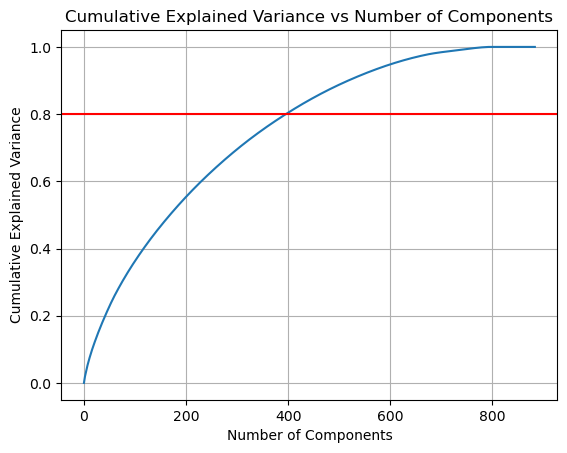

In [118]:
# Plotting the explained variance vs number of components plot
cum_evr = np.insert(cum_evr, 0, 0) # dummy variable so number of components starts at 1
plt.plot(cum_evr)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs Number of Components')
plt.axhline(y = 0.8, color = 'r', linestyle = '-')
#plt.xticks(np.arange(0,10))
plt.grid()
plt.show()

Keeping 80% of the explained variance in PCA is a common heuristic used to balance between reducing the dimensionality of the data while retaining a significant amount of information. By retaining 80% of the explained variance, we aim to capture the most relevant patterns and structures in the data while discarding the less informative components. This threshold strikes a balance between reducing computational complexity and retaining sufficient information for downstream analysis or modeling tasks. Additionally, it helps prevent overfitting by focusing on the most important features while disregarding noise or less relevant variability.

To account for ~80% of the cumulative explained variance, we need to keep ~400 components in PCA

In [119]:
# Perform PCA on the selected columns for all labels
pca = PCA(n_components= 400, random_state= 42)  # Reduce 6833 components to 500 components

# Initializing scaler
scaler = StandardScaler()

# Fitting and transforming on the training set
X_train_scaled = scaler.fit_transform(X_train[columns_for_pca]) 
X_test_scaled = scaler.transform(X_test[columns_for_pca])

# PCA
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Concatenate PCA-transformed features with remaining columns
X_train_final = np.concatenate([X_train[columns_to_exclude].values, X_train_pca], axis=1)
X_test_final = np.concatenate([ X_test[columns_to_exclude].values, X_test_pca], axis=1)

In [120]:
len(X_train_final[1]) # should be 400 + 27 from PCA + columns_to_exclude respectively

427

## Models:

For classification tasks such as these, some commonly used ML models include Logistic Regression, Random Forest, and k-NN. Let us try to deploy these 3 models and see which gives us the best model in terms of accuracy

### Logistic Regression

LR uses a linear combination of features, and the coefficients of these features affect the decision boundary. If features are on different scales, features with larger magnitudes might dominate the optimization process. Therefore, feature scaling is crucial for logistic regression to ensure that all features contribute equally to the model.

In [121]:
# Define base classifier (Log Reg)
base_classifier = LogisticRegression(max_iter = 10000, random_state = 42)

# Define multi-output classifier pipeline
multi_output_clf = MultiOutputClassifier(base_classifier)

# Scaling data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# Define and train model
multi_output_clf.fit(X_train_scaled, y_train)

# Evaluate model on test data
y_pred = multi_output_clf.predict(X_test_scaled)

# Testing accuracy
test_accuracy = accuracy_score(y_test, y_pred)

print("Testing Accuracy for Logistic Regression:", test_accuracy)

Testing Accuracy for Logistic Regression: 0.3837011884550085


In [122]:
# Define dict with label names
label_dict = {
    0: "Combination",
    1: "Dry",
    2: "Normal",
    3: "Oily",
    4: "Sensitive"
}

# Define function to compute accuracy for individual labels
def compute_label_accuracy(y_true, y_pred):
    label_accuracies = {}
    for i in range(y_true.shape[1]):
        label_accuracy = accuracy_score(y_true.iloc[:, i], y_pred[:, i])
        label_accuracies[f"{list(label_dict.values())[i]}"] = label_accuracy
    return label_accuracies

# Compute accuracy for individual labels
label_accuracies = compute_label_accuracy(y_test, y_pred)

# Print accuracy for each label
for label, accuracy in label_accuracies.items():
    print(f"Accuracy for Logistic Regression for {label}: {accuracy}")

Accuracy for Logistic Regression for Combination: 0.6859083191850595
Accuracy for Logistic Regression for Dry: 0.6689303904923599
Accuracy for Logistic Regression for Normal: 0.7079796264855688
Accuracy for Logistic Regression for Oily: 0.6570458404074703
Accuracy for Logistic Regression for Sensitive: 0.6400679117147708


### k-Nearest Neighbors:

KNN relies on the distance metric (e.g., Euclidean distance) to find nearest neighbors. If features are on different scales, the distance calculation might be biased towards features with larger scales. Therefore, feature scaling can significantly impact the performance of KNN.


In [123]:
# Define base classifier (KNN)
base_classifier = KNeighborsClassifier(n_neighbors= 5)

# Define multi-output classifier pipeline
multi_output_clf = MultiOutputClassifier(base_classifier)

# Scaling data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# Define and train model
multi_output_clf.fit(X_train_scaled, y_train)

# Evaluate model on test data
y_pred = multi_output_clf.predict(X_test_scaled)

# Testing accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print("Testing Accuracy for k-NN:", test_accuracy)

Testing Accuracy for k-NN: 0.3938879456706282


In [124]:
# Compute accuracy for individual labels
label_accuracies = compute_label_accuracy(y_test, y_pred)

# Print accuracy for each label
for label, accuracy in label_accuracies.items():
    print(f"Accuracy for k-NN for {label}: {accuracy}")

Accuracy for k-NN for Combination: 0.629881154499151
Accuracy for k-NN for Dry: 0.6196943972835314
Accuracy for k-NN for Normal: 0.6281833616298812
Accuracy for k-NN for Oily: 0.633276740237691
Accuracy for k-NN for Sensitive: 0.5874363327674024


### Random Forest Classifier:

RFC builds multiple decision trees and combines their predictions through averaging or voting, which makes it less sensitive to feature scaling. The algorithm splits nodes based on feature thresholds, and the relative ordering of features remains unchanged regardless of scaling.
Therefore we will not be scaling the features here.

In [125]:
# Define base classifier (RFC)
base_classifier = RandomForestClassifier(random_state= 42)

# Define multi-output classifier pipeline
multi_output_clf = MultiOutputClassifier(base_classifier)

# Define and train model
multi_output_clf.fit(X_train_final, y_train)

# Evaluate model
y_pred = multi_output_clf.predict(X_test_final)

# Testing accuracy
test_accuracy = accuracy_score(y_test, y_pred)

print("Testing Accuracy for RFC:", test_accuracy)

Testing Accuracy for RFC: 0.36502546689303905


In [126]:
# Compute accuracy for individual labels
label_accuracies = compute_label_accuracy(y_test, y_pred)

# Print accuracy for each label
for label, accuracy in label_accuracies.items():
    print(f"Accuracy for RFC for {label}: {accuracy}")

Accuracy for RFC for Combination: 0.6876061120543294
Accuracy for RFC for Dry: 0.6417657045840407
Accuracy for RFC for Normal: 0.6926994906621392
Accuracy for RFC for Oily: 0.6502546689303905
Accuracy for RFC for Sensitive: 0.631578947368421


## Grid search:

Let us perform grid search for the two models that had the highest accuracy - Logistic Regression and k-NN

Grid search for Logistic Regression:

In [127]:
# Define base classifier (Logistic Regression)
base_classifier = LogisticRegression()

# Define multi-output classifier pipeline
multi_output_clf = MultiOutputClassifier(base_classifier)

# Define parameter grid for hyperparameter tuning
param_grid = {
    'estimator__C': [0.001, 0.1, 1],
    'estimator__max_iter': [100, 200, 1000],
    'estimator__class_weight': [None, 'balanced']
}

# Perform grid search with 3-fold cross-validation
grid_search = GridSearchCV(estimator=multi_output_clf, param_grid=param_grid, cv=3, verbose=3, error_score='raise')

# Fit the grid search to the data
grid_search.fit(X_train_scaled, y_train)

# Print the best parameters found
print("Best parameters found:", grid_search.best_params_)


Fitting 3 folds for each of 18 candidates, totalling 54 fits


[CV 1/3] END estimator__C=0.001, estimator__class_weight=None, estimator__max_iter=100;, score=0.308 total time=   1.5s
[CV 2/3] END estimator__C=0.001, estimator__class_weight=None, estimator__max_iter=100;, score=0.401 total time=   0.7s
[CV 3/3] END estimator__C=0.001, estimator__class_weight=None, estimator__max_iter=100;, score=0.405 total time=   0.3s
[CV 1/3] END estimator__C=0.001, estimator__class_weight=None, estimator__max_iter=200;, score=0.308 total time=   0.1s
[CV 2/3] END estimator__C=0.001, estimator__class_weight=None, estimator__max_iter=200;, score=0.401 total time=   0.1s
[CV 3/3] END estimator__C=0.001, estimator__class_weight=None, estimator__max_iter=200;, score=0.405 total time=   0.1s
[CV 1/3] END estimator__C=0.001, estimator__class_weight=None, estimator__max_iter=1000;, score=0.308 total time=   0.1s
[CV 2/3] END estimator__C=0.001, estimator__class_weight=None, estimator__max_iter=1000;, score=0.401 total time=   0.2s
[CV 3/3] END estimator__C=0.001, estim

Fitting the best Logistic Regression model:

In [128]:
# Fit the model using the best parameters
best_log_reg = grid_search.best_params_
multi_output_clf.set_params(**best_log_reg)
multi_output_clf.fit(X_train_scaled, y_train)

# Prediction
y_pred = multi_output_clf.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy for Log Reg using grid search parameters:", accuracy)

Test accuracy for Log Reg using grid search parameters: 0.48047538200339557


In [129]:
# Compute accuracy for individual labels
label_accuracies = compute_label_accuracy(y_test, y_pred)

# Print accuracy for each label
for label, accuracy in label_accuracies.items():
    print(f"Accuracy for {label}: {accuracy}")

Accuracy for Combination: 0.7130730050933786
Accuracy for Dry: 0.7011884550084889
Accuracy for Normal: 0.735144312393888
Accuracy for Oily: 0.7113752122241087
Accuracy for Sensitive: 0.6859083191850595


Grid search for k-NN:

In [130]:
# Define base classifier (k-NN)
base_classifier = KNeighborsClassifier()

# Define multi-output classifier pipeline
multi_output_clf = MultiOutputClassifier(base_classifier)

# Define parameter grid for hyperparameter tuning
param_grid = {
    'estimator__n_neighbors': [3, 5, 7],
    'estimator__weights': ['uniform', 'distance'],
    'estimator__algorithm': ['auto', 'ball_tree', 'kd_tree']
}

# Perform grid search with 3-fold cross-validation
grid_search = GridSearchCV(estimator=multi_output_clf, param_grid=param_grid, cv=3, verbose=3, error_score='raise')

# Fit the grid search to the data
grid_search.fit(X_train_scaled, y_train)

# Print the best parameters found
print("Best parameters found:", grid_search.best_params_)

Fitting 3 folds for each of 18 candidates, totalling 54 fits


[CV 1/3] END estimator__algorithm=auto, estimator__n_neighbors=3, estimator__weights=uniform;, score=0.336 total time=   0.3s
[CV 2/3] END estimator__algorithm=auto, estimator__n_neighbors=3, estimator__weights=uniform;, score=0.408 total time=   0.1s
[CV 3/3] END estimator__algorithm=auto, estimator__n_neighbors=3, estimator__weights=uniform;, score=0.405 total time=   0.1s
[CV 1/3] END estimator__algorithm=auto, estimator__n_neighbors=3, estimator__weights=distance;, score=0.346 total time=   0.1s
[CV 2/3] END estimator__algorithm=auto, estimator__n_neighbors=3, estimator__weights=distance;, score=0.415 total time=   0.1s
[CV 3/3] END estimator__algorithm=auto, estimator__n_neighbors=3, estimator__weights=distance;, score=0.398 total time=   0.2s
[CV 1/3] END estimator__algorithm=auto, estimator__n_neighbors=5, estimator__weights=uniform;, score=0.322 total time=   0.2s
[CV 2/3] END estimator__algorithm=auto, estimator__n_neighbors=5, estimator__weights=uniform;, score=0.374 total ti

Fitting the best k-NN Model:

In [131]:
# Fit the model using the best parameters
multi_output_clf.set_params(**grid_search.best_params_)
multi_output_clf.fit(X_train_scaled, y_train)

# Prediction
y_pred = multi_output_clf.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy for k-NN using grid search parameters:", accuracy)

Test accuracy for k-NN using grid search parameters: 0.41256366723259763


In [132]:
# Compute accuracy for individual labels
label_accuracies = compute_label_accuracy(y_test, y_pred)

# Print accuracy for each label
for label, accuracy in label_accuracies.items():
    print(f"Accuracy for {label}: {accuracy}")

Accuracy for Combination: 0.6485568760611206
Accuracy for Dry: 0.631578947368421
Accuracy for Normal: 0.6451612903225806
Accuracy for Oily: 0.6570458404074703
Accuracy for Sensitive: 0.6044142614601019


**Results:**

We see that Logistic Regression provides the highest combined accuracy here - of ~48% on test data, and has a higher accuracy for each individual label than k-NN:

- Accuracy for Combination: 0.7130730050933786
- Accuracy for Dry: 0.7011884550084889
- Accuracy for Normal: 0.735144312393888
- Accuracy for Oily: 0.7113752122241087
- Accuracy for Sensitive: 0.6859083191850595

Therefore, this is the best model we have.

The suitability of logistic regression compared to k-nearest neighbors (KNN) or random forest classifier (RFC) depends on various factors such as the nature of the data, the assumptions of the model, and the specific objectives of the analysis. Here are some reasons why logistic regression might be preferred over KNN or RFC in certain situations:

1. **Interpretability**: Logistic regression provides clear interpretations of the relationship between independent variables and the log-odds of the outcome. This makes it easier to understand the impact of each predictor on the target variable compared to KNN or RFC, which are often considered as "black box" models.

2. **Linear Assumption**: Logistic regression assumes a linear relationship between the independent variables and the log-odds of the outcome. If the relationship is indeed linear or can be adequately approximated by a linear function, logistic regression might perform better than non-linear models like KNN or RFC.

3. **Handling Irrelevant Features**: Logistic regression can handle irrelevant features or noise in the data better than KNN or RFC. It assigns weights to each feature, which helps in identifying the most important predictors and ignoring less relevant ones.

4. **Binary Classification**: Logistic regression is specifically designed for binary classification tasks, where the outcome variable has two categories. If the problem at hand is binary classification, logistic regression might be a more natural choice.

Due to these reasons, it is possible that logistic regression performed better in our analysis.

Let us try to extend this and create a neural network model. Although it is not usual to create NN models using such small datasets, we can think of this as a template that can be used when more data is available.

## Neural Network Implementation:

We will be implementing a simple neural network with only 2 linear hidden layers. We will use X_train_scaled.

In most cases, it is beneficial to use scaled data in neural networks. Here's why:

1. **Faster convergence**: Neural networks often converge faster when the input features are scaled. This is because scaling ensures that all features have a similar range of values, which helps the optimization algorithm find the optimal solution more efficiently.

2. **Improved performance**: Scaling the input features can lead to better performance of the neural network model. Scaled features prevent certain features from dominating others simply because of their larger scale.

Overall, it is recommended to use scaled data in neural networks to achieve better convergence, performance, and stability during training. Therefore, in this case, it's advisable to use scaled data (`X_train_scaled` and `X_test_scaled`) for training the neural network model.

In [133]:
# Set random seed for NumPy
np.random.seed(42)

# Set random seed for TensorFlow
tf.random.set_seed(42)

# Define the neural network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.5),  # Adding dropout for regularization
    Dense(32, activation='relu'),
    Dropout(0.5),  # Adding dropout for regularization
    Dense(5, activation='softmax')  # Since we have 5 output classes for multi-label classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train_scaled, y_train,
                    epochs=10,  
                    batch_size=32,
                    validation_data=(X_test_scaled, y_test))

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test_scaled, y_test)
print('Test accuracy:', test_acc)

Epoch 1/10


/Users/namrataelamaran/anaconda3/envs/bmin5250/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3594 - loss: 1.0750 - val_accuracy: 0.2547 - val_loss: 0.6933
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2631 - loss: 0.8462 - val_accuracy: 0.1647 - val_loss: 0.6798
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2409 - loss: 0.7633 - val_accuracy: 0.1494 - val_loss: 0.6728
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2065 - loss: 0.7362 - val_accuracy: 0.1545 - val_loss: 0.6683
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2074 - loss: 0.7030 - val_accuracy: 0.1800 - val_loss: 0.6654
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2183 - loss: 0.6653 - val_accuracy: 0.2071 - val_loss: 0.6620
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2455 - loss: 0.6602 - val_accuracy: 0.2632 - val_loss: 0.6578
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2490 - loss: 0.6403 - val_accuracy: 0.3158 - val_loss: 0.6531
Epo

CNN:

In [136]:
# Set random seed for NumPy
np.random.seed(42)

# Set random seed for TensorFlow
tf.random.set_seed(42)

# Reshape data for CNN
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# Define CNN architecture
model = models.Sequential([
    layers.Conv1D(32, 3, activation='relu', input_shape=(X_train_scaled.shape[1], 1)),
    layers.MaxPooling1D(2),
    layers.Conv1D(64, 3, activation='relu'),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, 3, activation='relu'),
    layers.MaxPooling1D(2),
    layers.Conv1D(256, 3, activation='relu'),
    layers.MaxPooling1D(2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Add dropout for regularization
    layers.Dense(64, activation='relu'),
    layers.Dense(5, activation='sigmoid')  #  5 skin types
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train_reshaped, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(X_test_reshaped, y_test))

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test_reshaped, y_test)
print('Test accuracy:', test_acc)

Epoch 1/10


/Users/namrataelamaran/anaconda3/envs/bmin5250/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.2191 - loss: 0.6843 - val_accuracy: 0.0017 - val_loss: 0.6682
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4019 - loss: 0.6595 - val_accuracy: 0.0747 - val_loss: 0.6645
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3139 - loss: 0.6497 - val_accuracy: 0.4516 - val_loss: 0.6571
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.4463 - loss: 0.6310 - val_accuracy: 0.7199 - val_loss: 0.6458
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.4546 - loss: 0.6158 - val_accuracy: 0.6995 - val_loss: 0.6287
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.4215 - loss: 0.5697 - val_accuracy: 0.4822 - val_loss: 0.6140
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.2588 - loss: 0.5289 - val_accuracy: 0.6893 - val_loss: 0.6109
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.3449 - loss: 0.4687 - val_accuracy: 0.7572 - val_loss: 0.